In [1]:
import warnings

import os
import sys
import json
import re
import time 
import random
import math
import torch
import pandas as pd
import numpy as np  

import matplotlib.pyplot as plt

from typing import List, Tuple
from sklearn.model_selection import train_test_split

from transformers import pipeline
from transformers import set_seed
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification, Trainer, TrainingArguments
from transformers import DataCollatorForTokenClassification
from datasets import Dataset, DatasetDict
from evaluate import load
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning, module=".*torch.*")

In [2]:
data = pd.read_json("data/clean_data.json")
data.head()

,message_id,content
0,shackleton-s/sent/1912.,Message-ID: <21013688.1075844564560.JavaMail.e...
1,farmer-d/logistics/1066.,Message-ID: <22688499.1075854130303.JavaMail.e...
2,parks-j/deleted_items/202.,Message-ID: <27817771.1075841359502.JavaMail.e...
3,stokley-c/chris_stokley/iso/client_rep/41.,Message-ID: <10695160.1075858510449.JavaMail.e...
4,germany-c/all_documents/1174.,Message-ID: <27819143.1075853689038.JavaMail.e...


In [3]:
# Using Regex r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}"
# Manually annotate each email address in data dataset having email body as content column with a specific label for email. For example, you could use the label "EMAIL". Ensure that all words within the email address are correctly tagged (e.g., "john.doe@example.com" should be labeled as "EMAIL", not just "john.doe" or "example.com").
def annotate_emails(row):
    email_pattern = r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}"
    content = row['content']
    annotated_content = re.sub(email_pattern, lambda match: f"<EMAIL>{match.group(0)}</EMAIL>", content)
    return annotated_content

data['annotated_content'] = data.apply(annotate_emails, axis=1)
data[['content', 'annotated_content']].head()

,content,annotated_content
0,Message-ID: <21013688.1075844564560.JavaMail.e...,Message-ID: <21013688.1075844564560.JavaMail.e...
1,Message-ID: <22688499.1075854130303.JavaMail.e...,Message-ID: <22688499.1075854130303.JavaMail.e...
2,Message-ID: <27817771.1075841359502.JavaMail.e...,Message-ID: <27817771.1075841359502.JavaMail.e...
3,Message-ID: <10695160.1075858510449.JavaMail.e...,Message-ID: <10695160.1075858510449.JavaMail.e...
4,Message-ID: <27819143.1075853689038.JavaMail.e...,Message-ID: <27819143.1075853689038.JavaMail.e...


In [4]:
# Create new dataset with annotated content in  standard NER format IOBES for token-level classification and save new dataset as "data/anotated_data.json" you may drop original column content
def convert_to_iobes_format(row):
    tokens = row['annotated_content'].split()
    iobes_format = []
    for token in tokens:
        if token.startswith("<EMAIL>") and token.endswith("</EMAIL>"):
            email = token[7:-8]  # Remove <EMAIL> and </EMAIL>
            email_tokens = email.split(".")
            for i, email_token in enumerate(email_tokens):
                if i == 0:
                    iobes_format.append((email_token, "B-EMAIL"))
                elif i == len(email_tokens) - 1:
                    iobes_format.append((email_token, "E-EMAIL"))
                else:
                    iobes_format.append((email_token, "I-EMAIL"))
        else:
            iobes_format.append((token, "O"))
    return iobes_format

data['iobes_format'] = data.apply(convert_to_iobes_format, axis=1)

# Create a new dataset with the IOBES format
annotated_data = data[['message_id', 'iobes_format']]

annotated_data = annotated_data.sample(frac=0.1, random_state=42).reset_index(drop=True)
# Save the new dataset as "data/anotated_data.json"
annotated_data.to_json("data/anotated_data.json", orient="records", lines=True)

In [5]:
# Load tokenizer and model from the local directory
MODEL_NAME = "models/dslim-bert-base-NER"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, local_files_only=True)
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, local_files_only=True)

In [6]:
annotated_data.head()

,message_id,iobes_format
0,allen-p/sent/180.,"[(Message-ID:, O), (<23314850.1075855683680.Ja..."
1,linder-e/notes_inbox/767.,"[(Message-ID:, O), (<23001708.1075841062711.Ja..."
2,mclaughlin-e/deleted_items/235.,"[(Message-ID:, O), (<31019484.1075841234197.Ja..."
3,neal-s/sent/154.,"[(Message-ID:, O), (<26844661.1075858417930.Ja..."
4,keavey-p/all_documents/66.,"[(Message-ID:, O), (<9146229.1075855626048.Jav..."


In [7]:
# Tokenize annotated_data using tokenizer loaded from transformers and loaded from a pre-trained model

def tokenize_and_align_labels(examples):
    # Extract tokens from iobes_format
    tokens = [[token[0] for token in example] for example in examples['iobes_format']]
    
    tokenized_inputs = tokenizer(
        tokens, 
        truncation=True, 
        is_split_into_words=True, 
        padding=True, 
        max_length=512
    )
    
    labels = []
    for i, label in enumerate(examples['iobes_format']):
        word_ids = tokenized_inputs.word_ids(batch_index=i)  # Map tokens to their respective word.
        label_ids = []
        previous_word_idx = None
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)  # Special tokens
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx][1])  # Assign label to the first token of the word
            else:
                label_ids.append(-100)  # Assign -100 to subsequent tokens of the same word
            previous_word_idx = word_idx
        labels.append(label_ids)
    
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Convert annotated_data to Dataset format
dataset = Dataset.from_pandas(annotated_data)

# Tokenize the dataset
# Map the dataset and convert labels to integers
label_to_id = {"O": 0, "B-EMAIL": 1, "I-EMAIL": 2, "E-EMAIL": 3}  # Define a mapping for labels
id_to_label = {v: k for k, v in label_to_id.items()}  # Reverse mapping for reference

def tokenize_and_align_labels_with_conversion(examples):
    tokenized_inputs = tokenize_and_align_labels(examples)
    # Convert labels to integers using the label_to_id mapping
    tokenized_inputs["labels"] = [
        [label_to_id[label] if label != -100 else -100 for label in labels]
        for labels in tokenized_inputs["labels"]
    ]
    return tokenized_inputs

tokenized_dataset = dataset.map(tokenize_and_align_labels_with_conversion, batched=True)

Map:   0%|          | 0/10348 [00:00<?, ? examples/s]

In [8]:
# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",  # Directory to save model checkpoints and logs
    eval_strategy="epoch",  # Evaluate at the end of each epoch
    learning_rate=5e-5,  # Learning rate
    per_device_train_batch_size=16,  # Batch size for training
    per_device_eval_batch_size=16,  # Batch size for evaluation
    num_train_epochs=3,  # Number of epochs
    weight_decay=0.01,  # Weight decay for regularization
    logging_dir="./logs",  # Directory for logs
    logging_steps=10,  # Log every 10 steps
    save_strategy="epoch",  # Save model at the end of each epoch
    save_total_limit=2,  # Limit the number of saved checkpoints
    load_best_model_at_end=True,  # Load the best model at the end of training
    metric_for_best_model="eval_loss",  # Metric to determine the best model
    report_to="none"  # Disable reporting to external services
)

# Define a data collator for token classification
data_collator = DataCollatorForTokenClassification(tokenizer)

# Load evaluation metric
metric = load("seqeval")

# Define a compute_metrics function for evaluation
def compute_metrics(pred):
    predictions, labels = pred
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (-100) and convert labels to strings
    true_labels = [
        [id_to_label[label] for label in label_row if label != -100]
        for label_row in labels
    ]
    true_predictions = [
        [id_to_label[pred] for (pred, label) in zip(pred_row, label_row) if label != -100]
        for pred_row, label_row in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

# Split the dataset into training and validation sets
train_test_split = tokenized_dataset.train_test_split(test_size=0.2)
train_dataset = train_test_split["train"]
eval_dataset = train_test_split["test"]

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.001800,0.004442,0.941877,0.978397,0.959790,0.998590
2,0.003000,0.003217,0.964137,0.982829,0.973393,0.999094
3,0.002700,0.003127,0.968159,0.982459,0.975257,0.999189


TrainOutput(global_step=1554, training_loss=0.0060579645686556355, metrics={'train_runtime': 1594.192, 'train_samples_per_second': 15.578, 'train_steps_per_second': 0.975, 'total_flos': 6489454326110208.0, 'train_loss': 0.0060579645686556355, 'epoch': 3.0})

In [9]:
# Evaluate the model on the test set
evaluation_results = trainer.evaluate(eval_dataset=eval_dataset)

# Print the evaluation results
print("Evaluation Results:")
for metric_name, metric_value in evaluation_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

Evaluation Results:
eval_loss: 0.0031
eval_precision: 0.9682
eval_recall: 0.9825
eval_f1: 0.9753
eval_accuracy: 0.9992
eval_runtime: 39.6692
eval_samples_per_second: 52.1820
eval_steps_per_second: 3.2770
epoch: 3.0000


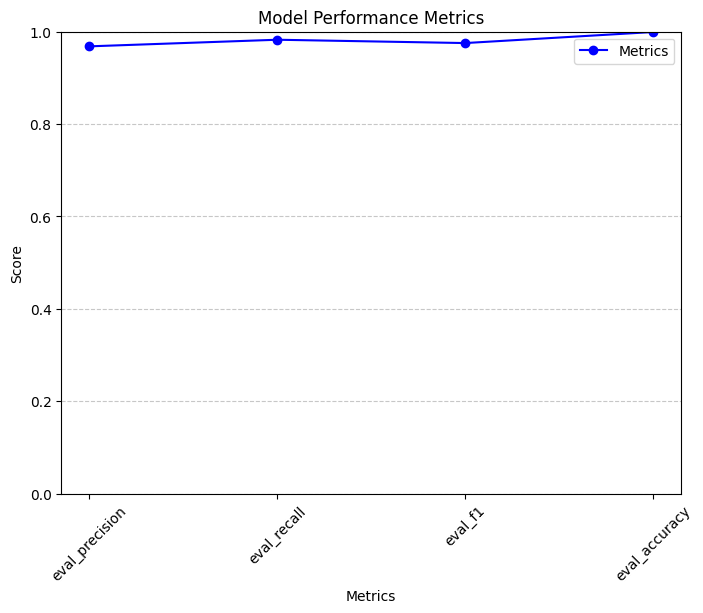

In [14]:
# Extract metrics from evaluation results
metrics = ['eval_precision', 'eval_recall', 'eval_f1', 'eval_accuracy']
values = [evaluation_results[metric] for metric in metrics]
# Create an xy-style plot for the metrics
plt.figure(figsize=(8, 6))
plt.plot(metrics, values, marker='o', linestyle='-', color='blue', label='Metrics')
plt.title('Model Performance Metrics')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)  # Metrics are between 0 and 1
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

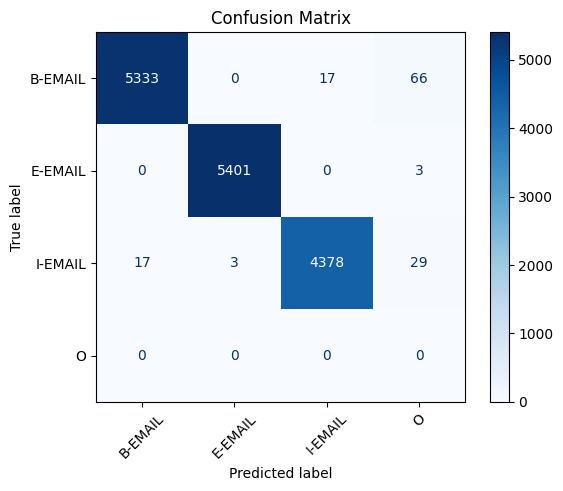

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Flatten the true and predicted labels
flat_true_labels = [label for sublist in true_labels for label in sublist]
flat_predicted_labels = [label for sublist in true_predictions for label in sublist]

# Filter out ignored labels (-100)
filtered_true_labels = [label for label in flat_true_labels if label != "O"]
filtered_predicted_labels = [flat_predicted_labels[i] for i in range(len(flat_true_labels)) if flat_true_labels[i] != "O"]

# Get unique labels
unique_labels = sorted(set(filtered_true_labels + filtered_predicted_labels))

# Compute confusion matrix
cm = confusion_matrix(filtered_true_labels, filtered_predicted_labels, labels=unique_labels)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [15]:
def extract_emails_from_predictions(predictions, labels):
    emails = []
    current_email = []
    
    for prediction, label in zip(predictions, labels):
        if label == "B-EMAIL":
            if current_email:
                emails.append("".join(current_email))
                current_email = []
            current_email.append(prediction)
        elif label == "I-EMAIL" or label == "E-EMAIL":
            current_email.append(prediction)
        elif current_email:
            emails.append("".join(current_email))
            current_email = []
    
    if current_email:
        emails.append("".join(current_email))
    
    return emails

# Example usage
predictions = ["john", ".", "doe", "@", "example", ".", "com", "other", "text"]
labels = ["B-EMAIL", "I-EMAIL", "I-EMAIL", "I-EMAIL", "I-EMAIL", "E-EMAIL", "O", "O", "O"]

extracted_emails = extract_emails_from_predictions(predictions, labels)
print("Extracted Emails:", extracted_emails)

Extracted Emails: ['john.doe@example.']


In [17]:
# Update extract_emails_from_predictions to handle tokenized predictions
def extract_emails_from_predictions(predictions, labels):
    emails = []
    current_email = []
    
    for prediction, label in zip(predictions, labels):
        if label == "B-EMAIL":
            if current_email:
                emails.append("".join(current_email))
                current_email = []
            current_email.append(prediction)
        elif label in ["I-EMAIL", "E-EMAIL"]:
            current_email.append(prediction)
        elif current_email:
            emails.append("".join(current_email))
            current_email = []
    
    if current_email:
        emails.append("".join(current_email))
    
    # Remove special tokens like '[unused2]' or '[PAD]'
    cleaned_emails = []
    for email in emails:
        cleaned_email = email.replace("[PAD]", "").replace("[unused2]", "").strip()
        if cleaned_email:  # Only add non-empty emails
            cleaned_emails.append(cleaned_email)
    
    return cleaned_emails


# Detokenize predictions before extracting emails
def detokenize_predictions(predictions):
    return tokenizer.convert_ids_to_tokens(predictions, skip_special_tokens=True)

# Detokenize and extract emails
extracted_emails_test = []
for pred, label in zip(predicted_labels, raw_labels):
    detokenized_pred = detokenize_predictions(pred)
    detokenized_label = [id_to_label[l] for l in label if l != -100]
    extracted_emails_test.extend(extract_emails_from_predictions(detokenized_pred, detokenized_label))

print("Extracted Emails from Test Data:", extracted_emails_test)

Extracted Emails from Test Data: ['[unused3][unused3][unused1]', '[unused3][unused3]', '[unused1]', '[unused1]', '[unused3][unused1]', '[unused3][unused1]', '[unused3][unused1]', '[unused3][unused1]', '[unused3]', '[unused3][unused1]', '[unused3]', '[unused1]', '[unused3]', '[unused3][unused1]', '[unused3]', '[unused3]', '[unused3][unused3]', '[unused3][unused1]', '[unused1][unused1]', '[unused1]', '[unused1]', '[unused3][unused1]', '[unused3]', '[unused3]', '[unused3]', '[unused3]', '[unused3][unused3]', '[unused3][unused3]', '[unused3][unused1]', '[unused1]', '[unused3][unused1]', '[unused3][unused1][unused1]', '[unused3]', '[unused3][unused1]', '[unused3][unused1]', '[unused3]', '[unused1][unused1]', '[unused3]', '[unused3][unused1]', '[unused3][unused3]', '[unused1]', '[unused1][unused1][unused1]', '[unused3]', '[unused3]', '[unused3][unused1]', '[unused3]', '[unused1]', '[unused3][unused1]', '[unused3]', '[unused3]', '[unused3][unused1]', '[unused3]', '[unused1]', '[unused3][unuse

In [13]:
# Define the labels and their corresponding IDs
# Step 4: Define the evaluation metric
metric = load("seqeval")

def compute_metrics(pred):
    """
    Computes evaluation metrics for the model.

    Args:
        pred (EvalPrediction): The predictions from the model.

    Returns:
        dict: A dictionary containing evaluation metrics.
    """
    predictions, labels = pred
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (special tokens)
    true_predictions = [
        [ID2LABEL[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [ID2LABEL[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [19]:
from gensim.models import Word2Vec

# Example sentences
sentences = [["hello", "world"], ["machine", "learning"], ["hello", "machine"]]

# Train a Word2Vec model
model = Word2Vec(sentences, vector_size=10, window=5, min_count=1, workers=1)

# Access the key_to_index attribute
print(model.wv.key_to_index)

{'machine': 0, 'hello': 1, 'learning': 2, 'world': 3}
